# Phase 4: Industry–Occupation Mix and Exposure Impact

This notebook summarizes industry–occupation exposure mix and explores exposure vs cumulative demand growth.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_root(start: Path) -> Path:
    here = start.resolve()
    for p in [here] + list(here.parents):
        if (p / 'Results Datasets' / 'final_analysis_dataset.parquet').exists():
            return p
    raise FileNotFoundError('Could not find Results Datasets/final_analysis_dataset.parquet')

ROOT = find_root(Path.cwd())
DATA_PATH = ROOT / 'Results Datasets' / 'final_analysis_dataset.parquet'
OUT_BASE = ROOT / 'Results Datasets' / 'analysis' / 'phase4_exposure_impact'
OUT_TABLES = OUT_BASE / 'tables'
OUT_VIS = OUT_BASE / 'visuals'
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_VIS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df = df[(df['adve_time_year'] >= 2010) & (df['adve_time_year'] <= 2024)].copy()

WEIGHT = 'srvy_wght_tru2'
occ_exp_col = 'occupation_exposure'
ind_exp_col = 'industry_exposure_weighted'

def _finite_for_plot(df_in, xcol, ycol, y_positive=False):
    tmp = df_in.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol, ycol])
    if y_positive:
        tmp = tmp[tmp[ycol] > 0]
    return tmp

def _wmean(series, weights):
    if series.empty:
        return np.nan
    return np.average(series, weights=weights)

def weighted_quantile(values, weights, q):
    v = np.asarray(values)
    w = np.asarray(weights)
    m = np.isfinite(v) & np.isfinite(w)
    if not m.any():
        return np.nan
    v = v[m]
    w = w[m]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    cum = np.cumsum(w)
    cutoff = q * cum[-1]
    return v[np.searchsorted(cum, cutoff)]

occ_p80 = weighted_quantile(df[occ_exp_col], df[WEIGHT], 0.80)

# Label fallbacks if missing
if 'comp_indu_noga_label' not in df.columns and 'comp_indu_noga' in df.columns:
    df['comp_indu_noga_label'] = df['comp_indu_noga'].astype(str)
if 'occu_isco2_label' not in df.columns and 'occu_isco_2008' in df.columns:
    raw = df['occu_isco_2008'].astype(str).str.strip()
    raw = raw.str.split('.', n=1).str[0]
    df['occu_isco2_label'] = raw.str.zfill(4).str[:2]

noga_label_col = 'industry_section_label' if 'industry_section_label' in df.columns else ('noga_section_label' if 'noga_section_label' in df.columns else None)
isco2_label_col = 'occu_isco2_label' if 'occu_isco2_label' in df.columns else None


## 4.1 Industry–occupation exposure mix (comp_indu_noga)


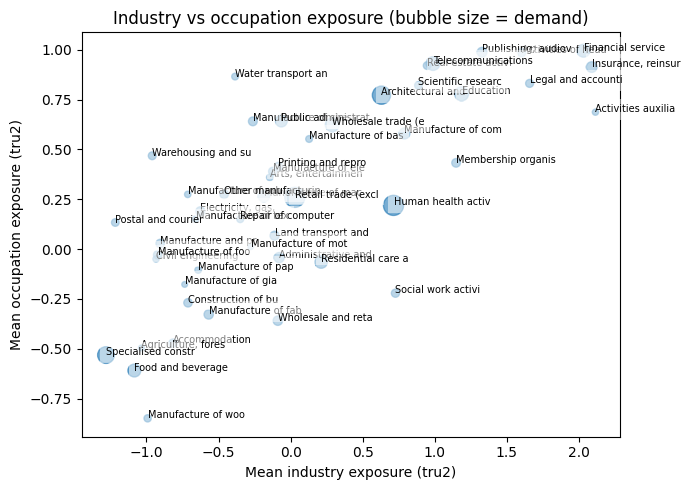

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble.png
Pearson: 0.7389407993948134
Spearman: 0.7388775510204082
Weighted Pearson: 0.8005239884029244
Demand vs ind exposure Pearson: 0.18374627860609496
Demand vs ind exposure Spearman: 0.32357142857142857
Demand vs ind exposure Weighted Pearson: 0.10154224398132866
Demand vs occ exposure Pearson: 0.09449938433922589
Demand vs occ exposure Spearman: 0.15775510204081633
Demand vs occ exposure Weighted Pearson: 0.0034753956328008526


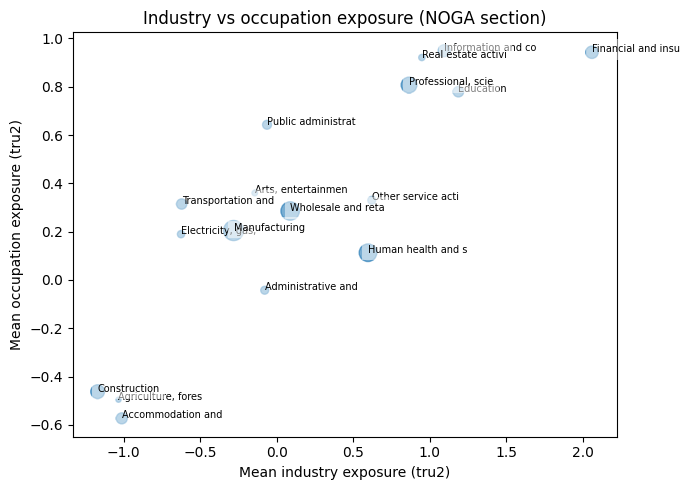

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_noga_section.png
noga_section Pearson: 0.8533950670974755
noga_section Spearman: 0.8406862745098039
noga_section Weighted Pearson: 0.844867571648986
noga_section Demand vs ind exposure Pearson: 0.09431413601243581
noga_section Demand vs ind exposure Spearman: 0.18872549019607843
noga_section Demand vs ind exposure Weighted Pearson: -0.12643440831797798
noga_section Demand vs occ exposure Pearson: 0.004620884549593317
noga_section Demand vs occ exposure Spearman: 0.03676470588235294
noga_section Demand vs occ exposure Weighted Pearson: -0.1389746663561954


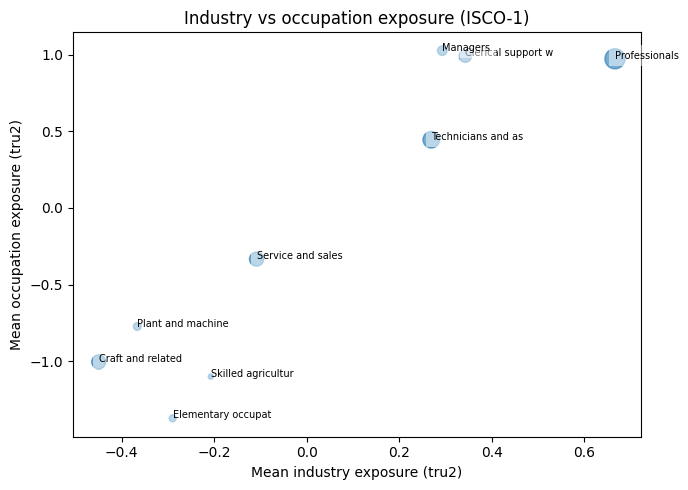

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_isco1.png
isco1 Pearson: 0.9235169055044401
isco1 Spearman: 0.8
isco1 Weighted Pearson: 0.9468149532509863
isco1 Demand vs ind exposure Pearson: 0.6523070155211343
isco1 Demand vs ind exposure Spearman: 0.48333333333333334
isco1 Demand vs ind exposure Weighted Pearson: 0.7310903769850251
isco1 Demand vs occ exposure Pearson: 0.5593671198825327
isco1 Demand vs occ exposure Spearman: 0.5166666666666667
isco1 Demand vs occ exposure Weighted Pearson: 0.5429573905602479


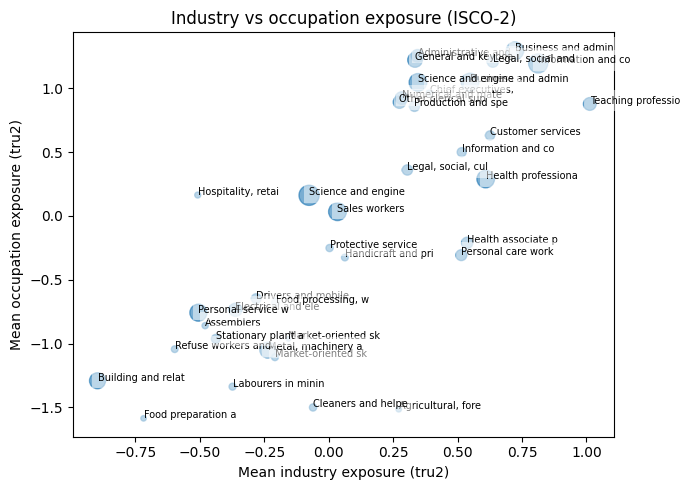

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_isco2.png
isco2 Pearson: 0.7685607779540443
isco2 Spearman: 0.7667140825035562
isco2 Weighted Pearson: 0.8342674119826401
isco2 Demand vs ind exposure Pearson: 0.283726729211306
isco2 Demand vs ind exposure Spearman: 0.422475106685633
isco2 Demand vs ind exposure Weighted Pearson: 0.09480149064344344
isco2 Demand vs occ exposure Pearson: 0.4333983223844126
isco2 Demand vs occ exposure Spearman: 0.5410876463508042
isco2 Demand vs occ exposure Weighted Pearson: 0.2239060339164724


In [2]:
# Industry-level mix (comp_indu_noga)
ind_mix = df.groupby(df['comp_indu_noga_label'].fillna('Unknown')).apply(
    lambda g: pd.Series({
        'demand_total_tru2': g[WEIGHT].sum(),
        'mean_ind_exp': np.average(g[ind_exp_col].dropna(), weights=g.loc[g[ind_exp_col].notna(), WEIGHT]) if g[ind_exp_col].notna().any() else np.nan,
        'mean_occ_exp': np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(), WEIGHT]) if g[occ_exp_col].notna().any() else np.nan,
        'share_high_occ_p80': (
            g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), WEIGHT].sum() /
            g.loc[g[occ_exp_col].notna(), WEIGHT].sum()
        ) if g[occ_exp_col].notna().any() else np.nan,
        'coverage': g.loc[g[occ_exp_col].notna(), WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan,
    })
).reset_index().rename(columns={'comp_indu_noga_label':'indu_label'})

ind_mix.to_csv(OUT_TABLES / 'table_ind_occ_mix.csv', index=False)

plt.figure(figsize=(7,5))
ind_mix_plot = _finite_for_plot(ind_mix, 'mean_ind_exp', 'mean_occ_exp', y_positive=False)
ind_mix_plot = ind_mix_plot[ind_mix_plot['demand_total_tru2'] > 0]
plt.scatter(
    ind_mix_plot['mean_ind_exp'],
    ind_mix_plot['mean_occ_exp'],
    s=(ind_mix_plot['demand_total_tru2'] / ind_mix_plot['demand_total_tru2'].max())*200 + 10,
    alpha=0.6
)
for _, row in ind_mix_plot.iterrows():
    plt.text(row['mean_ind_exp'], row['mean_occ_exp'], str(row['indu_label'])[:18], fontsize=7,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
plt.xlabel('Mean industry exposure (tru2)')
plt.ylabel('Mean occupation exposure (tru2)')
plt.title('Industry vs occupation exposure (bubble size = demand)')
plt.tight_layout()
fig_path = OUT_VIS / 'fig_ind_vs_occ_exposure_bubble.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)

valid = ind_mix.dropna(subset=['mean_ind_exp', 'mean_occ_exp'])
pearson = valid[['mean_ind_exp','mean_occ_exp']].corr().iloc[0,1]
spearman = valid[['mean_ind_exp','mean_occ_exp']].corr(method='spearman').iloc[0,1]
w = valid['demand_total_tru2'].to_numpy()
xi = valid['mean_ind_exp'].to_numpy()
yi = valid['mean_occ_exp'].to_numpy()
wmx = np.average(xi, weights=w)
wmy = np.average(yi, weights=w)
wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

print('Pearson:', pearson)
print('Spearman:', spearman)
print('Weighted Pearson:', weighted_pearson)

valid_d = valid.dropna(subset=['demand_total_tru2', 'mean_ind_exp', 'mean_occ_exp'])
if not valid_d.empty:
    pearson_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr().iloc[0,1]
    spearman_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr(method='spearman').iloc[0,1]
    pearson_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr().iloc[0,1]
    spearman_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr(method='spearman').iloc[0,1]

    w_d = valid_d['demand_total_tru2'].to_numpy()
    xd = valid_d['demand_total_tru2'].to_numpy()
    yi = valid_d['mean_ind_exp'].to_numpy()
    yo = valid_d['mean_occ_exp'].to_numpy()
    wmx = (xd * w_d).sum() / w_d.sum()
    wmy_i = (yi * w_d).sum() / w_d.sum()
    wmy_o = (yo * w_d).sum() / w_d.sum()
    wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
    wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
    wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
    weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
    weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

    print('Demand vs ind exposure Pearson:', pearson_d_ind)
    print('Demand vs ind exposure Spearman:', spearman_d_ind)
    print('Demand vs ind exposure Weighted Pearson:', weighted_pearson_d_ind)
    print('Demand vs occ exposure Pearson:', pearson_d_occ)
    print('Demand vs occ exposure Spearman:', spearman_d_occ)
    print('Demand vs occ exposure Weighted Pearson:', weighted_pearson_d_occ)

# === Industry-level mix: NOGA section + ISCO-1/2 ===
def industry_mix_by(group_label_col, exp_col, out_suffix, title):
    if group_label_col is None or group_label_col not in df.columns:
        print(f'Skipping {out_suffix}: {group_label_col} not in dataset')
        return
    mix = df.groupby(df[group_label_col].fillna('Unknown')).apply(
        lambda g: pd.Series({
            'demand_total_tru2': g[WEIGHT].sum(),
            'mean_ind_exp': np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT]) if g[exp_col].notna().any() else np.nan,
            'mean_occ_exp': np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(), WEIGHT]) if g[occ_exp_col].notna().any() else np.nan,
            'share_high_occ_p80': (
                g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), WEIGHT].sum() /
                g.loc[g[occ_exp_col].notna(), WEIGHT].sum()
            ) if g[occ_exp_col].notna().any() else np.nan,
            'coverage': g.loc[g[occ_exp_col].notna(), WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan,
        })
    ).reset_index().rename(columns={group_label_col: 'indu_label'})

    mix.to_csv(OUT_TABLES / f'table_ind_occ_mix_{out_suffix}.csv', index=False)

    plt.figure(figsize=(7,5))
    mix_plot = _finite_for_plot(mix, 'mean_ind_exp', 'mean_occ_exp', y_positive=False)
    mix_plot = mix_plot[mix_plot['demand_total_tru2'] > 0]
    plt.scatter(mix_plot['mean_ind_exp'], mix_plot['mean_occ_exp'],
                s=(mix_plot['demand_total_tru2'] / mix_plot['demand_total_tru2'].max())*200+10,
                alpha=0.6)
    for _, row in mix_plot.iterrows():
        plt.text(row['mean_ind_exp'], row['mean_occ_exp'], str(row['indu_label'])[:18], fontsize=7,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    plt.xlabel('Mean industry exposure (tru2)')
    plt.ylabel('Mean occupation exposure (tru2)')
    plt.title(title)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ind_vs_occ_exposure_bubble_{out_suffix}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    valid = mix.dropna(subset=['mean_ind_exp', 'mean_occ_exp'])
    pearson = valid[['mean_ind_exp','mean_occ_exp']].corr().iloc[0,1]
    spearman = valid[['mean_ind_exp','mean_occ_exp']].corr(method='spearman').iloc[0,1]
    w = valid['demand_total_tru2'].to_numpy()
    xi = valid['mean_ind_exp'].to_numpy()
    yi = valid['mean_occ_exp'].to_numpy()
    wmx = np.average(xi, weights=w)
    wmy = np.average(yi, weights=w)
    wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
    wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
    wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
    weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

    print(f'{out_suffix} Pearson:', pearson)
    print(f'{out_suffix} Spearman:', spearman)
    print(f'{out_suffix} Weighted Pearson:', weighted_pearson)

    valid_d = valid.dropna(subset=['demand_total_tru2', 'mean_ind_exp', 'mean_occ_exp'])
    if not valid_d.empty:
        pearson_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr().iloc[0,1]
        spearman_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr(method='spearman').iloc[0,1]
        pearson_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr().iloc[0,1]
        spearman_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr(method='spearman').iloc[0,1]

        w_d = valid_d['demand_total_tru2'].to_numpy()
        xd = valid_d['demand_total_tru2'].to_numpy()
        yi = valid_d['mean_ind_exp'].to_numpy()
        yo = valid_d['mean_occ_exp'].to_numpy()
        wmx = (xd * w_d).sum() / w_d.sum()
        wmy_i = (yi * w_d).sum() / w_d.sum()
        wmy_o = (yo * w_d).sum() / w_d.sum()
        wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
        wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
        wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
        weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
        weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

        print(f'{out_suffix} Demand vs ind exposure Pearson:', pearson_d_ind)
        print(f'{out_suffix} Demand vs ind exposure Spearman:', spearman_d_ind)
        print(f'{out_suffix} Demand vs ind exposure Weighted Pearson:', weighted_pearson_d_ind)
        print(f'{out_suffix} Demand vs occ exposure Pearson:', pearson_d_occ)
        print(f'{out_suffix} Demand vs occ exposure Spearman:', spearman_d_occ)
        print(f'{out_suffix} Demand vs occ exposure Weighted Pearson:', weighted_pearson_d_occ)

noga_label_col = 'industry_section_label' if 'industry_section_label' in df.columns else 'noga_section_label'
industry_mix_by(noga_label_col, ind_exp_col, 'noga_section', 'Industry vs occupation exposure (NOGA section)')
industry_mix_by('occu_isco1_label', ind_exp_col, 'isco1', 'Industry vs occupation exposure (ISCO-1)')
industry_mix_by('occu_isco2_label', ind_exp_col, 'isco2', 'Industry vs occupation exposure (ISCO-2)')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_29007/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


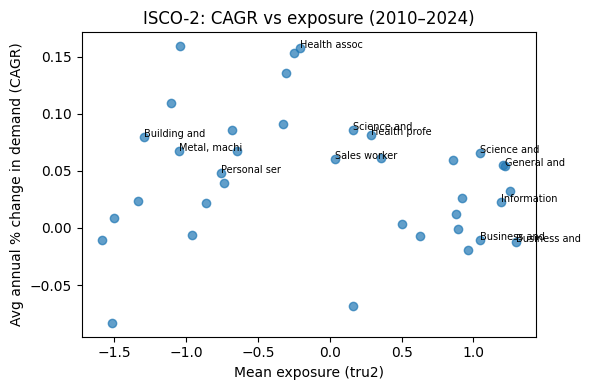

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_vs_exposure_isco2.png
ISCO-2: CAGR vs exposure (2010–2024) Pearson: -0.1395045785688686
ISCO-2: CAGR vs exposure (2010–2024) Spearman: -0.18255097202465623


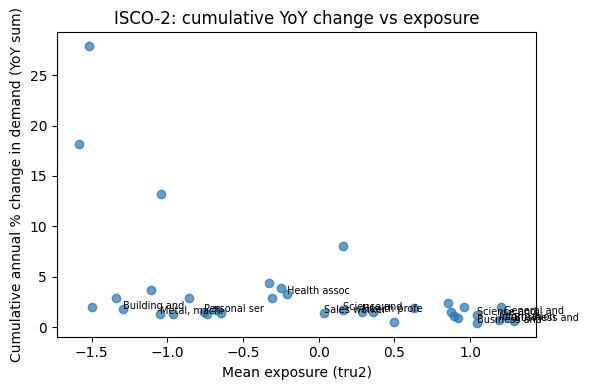

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_vs_exposure_isco2.png
ISCO-2: cumulative YoY change vs exposure Pearson: -0.4706696839697325
ISCO-2: cumulative YoY change vs exposure Spearman: -0.5806069227121858


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_29007/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


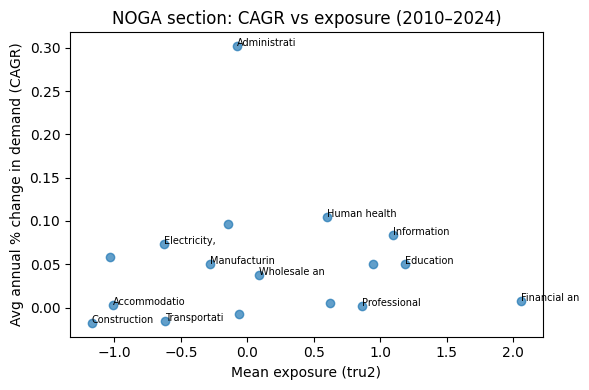

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_vs_exposure_noga_section.png
NOGA section: CAGR vs exposure (2010–2024) Pearson: 0.02606184083838617
NOGA section: CAGR vs exposure (2010–2024) Spearman: 0.12745098039215685


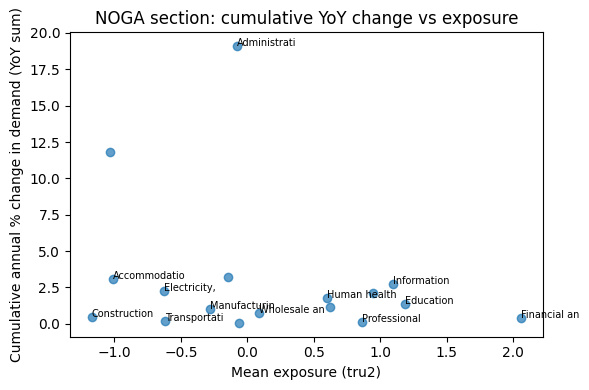

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_vs_exposure_noga_section.png
NOGA section: cumulative YoY change vs exposure Pearson: -0.24451107117299675
NOGA section: cumulative YoY change vs exposure Spearman: -0.22058823529411764


In [4]:
# --- Exposure impact: demand change vs exposure (ISCO-2 and NOGA section)
# Metrics:
# - CAGR: ((last/first)^(1/years) - 1)
# - cumulative_yoy: sum of year-over-year % changes
# - period changes: avg(2010–14) -> avg(2020–24) and avg(2015–19) -> avg(2020–24)

PERIODS = [(2010, 2014, '2010-2014'), (2015, 2019, '2015-2019'), (2020, 2024, '2020-2024')]

def _period_label(y):
    for a,b,lbl in PERIODS:
        if a <= y <= b:
            return lbl
    return None

def _group_demand_series(df, group_col):
    return (
        df.groupby([group_col, 'adve_time_year'])[WEIGHT]
          .sum()
          .reset_index()
    )

def _group_mean_exposure(df, group_col, exp_col):
    return (
        df.groupby(group_col)
          .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])
                 if g[exp_col].notna().any() else np.nan)
          .rename('mean_exposure')
    )

def _compute_change_metrics(df, group_col, exp_col, out_tag):
    # years
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    series = _group_demand_series(df, group_col)
    exp = _group_mean_exposure(df, group_col, exp_col)

    # first/last demand
    first = series[series['adve_time_year'] == y0].set_index(group_col)[WEIGHT]
    last = series[series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    out = pd.DataFrame({'mean_exposure': exp, 'demand_first': first, 'demand_last': last}).reset_index().rename(columns={group_col:'group'})
    out = out.dropna(subset=['demand_first','demand_last','mean_exposure'])
    out = out[(out['demand_first'] > 0) & (out['demand_last'] > 0)]

    # CAGR
    out['cagr'] = (out['demand_last'] / out['demand_first']) ** (1 / n_years) - 1

    # cumulative YoY change
    yoy = series.copy()
    yoy['prev'] = yoy.groupby(group_col)[WEIGHT].shift(1)
    yoy['yoy'] = yoy[WEIGHT] / yoy['prev'] - 1
    cum_yoy = yoy.groupby(group_col)['yoy'].sum().rename('cumulative_yoy')
    out = out.merge(cum_yoy, left_on='group', right_index=True, how='left')

    # period averages
    series['period'] = series['adve_time_year'].map(_period_label)
    period_avg = (
        series.dropna(subset=['period'])
              .groupby([group_col, 'period'])[WEIGHT]
              .mean()
              .unstack()
    )
    out = out.merge(period_avg, left_on='group', right_index=True, how='left')
    if '2010-2014' in out.columns and '2020-2024' in out.columns:
        out['pct_change_2010_2014_to_2020_2024'] = (out['2020-2024'] / out['2010-2014']) - 1
    if '2015-2019' in out.columns and '2020-2024' in out.columns:
        out['pct_change_2015_2019_to_2020_2024'] = (out['2020-2024'] / out['2015-2019']) - 1
    if all(col in out.columns for col in ['2010-2014','2015-2019','2020-2024']):
        out['avg_period_demand'] = out[['2010-2014','2015-2019','2020-2024']].mean(axis=1)

    out.to_csv(OUT_TABLES / f'table_demand_change_metrics_{out_tag}.csv', index=False)
    return out


def _scatter_with_corr(df, x_col, y_col, label, out_tag, y_label):
    tmp = df.dropna(subset=[x_col, y_col])
    if tmp.empty:
        print(f"Skipping {out_tag}: no data")
        return
    plt.figure(figsize=(6,4))
    plt.scatter(tmp[x_col], tmp[y_col], alpha=0.7)
    for _, row in tmp.nlargest(12, 'demand_last').iterrows():
        plt.text(row[x_col], row[y_col], str(row['group'])[:12], fontsize=7)
    plt.xlabel('Mean exposure (tru2)')
    plt.ylabel(y_label)
    plt.title(label)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_{out_tag}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    pearson = tmp[[x_col, y_col]].corr().iloc[0,1]
    spearman = tmp[[x_col, y_col]].corr(method='spearman').iloc[0,1]
    print(f"{label} Pearson:", pearson)
    print(f"{label} Spearman:", spearman)


# ISCO-2 (occupation exposure)
if 'occu_isco2_label' in df.columns:
    m_isco2 = _compute_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', 'isco2')
    _scatter_with_corr(
        m_isco2, 'mean_exposure', 'cagr',
        'ISCO-2: CAGR vs exposure (2010–2024)',
        'cagr_vs_exposure_isco2',
        'Avg annual % change in demand (CAGR)'
    )
    _scatter_with_corr(
        m_isco2, 'mean_exposure', 'cumulative_yoy',
        'ISCO-2: cumulative YoY change vs exposure',
        'cumyoy_vs_exposure_isco2',
        'Cumulative annual % change in demand (YoY sum)'
    )

# NOGA section (industry exposure)
if noga_label_col:
    m_noga = _compute_change_metrics(df, noga_label_col, 'industry_exposure_weighted', 'noga_section')
    _scatter_with_corr(
        m_noga, 'mean_exposure', 'cagr',
        'NOGA section: CAGR vs exposure (2010–2024)',
        'cagr_vs_exposure_noga_section',
        'Avg annual % change in demand (CAGR)'
    )
    _scatter_with_corr(
        m_noga, 'mean_exposure', 'cumulative_yoy',
        'NOGA section: cumulative YoY change vs exposure',
        'cumyoy_vs_exposure_noga_section',
        'Cumulative annual % change in demand (YoY sum)'
    )
